In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Loading Data

In [33]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

In [34]:
station = df_bike_counts["station"]
bike_count = df_bike_counts["bike_count"]
datetime = pd.to_datetime(df_bike_counts["datetime"])

year, month, day, hour, day_name = datetime.dt.year, datetime.dt.month, datetime.dt.day, datetime.dt.hour, datetime.dt.day_name

### Hourly Rate

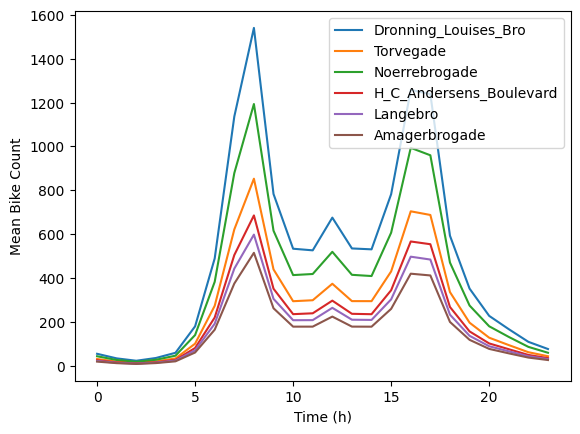

In [35]:
def mean_hourly_rate(Station):
    df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
    df_bike_counts["hour"] = df_bike_counts["datetime"].dt.hour

    mean_hourly = (
        df_bike_counts[df_bike_counts["station"] == Station]
        .groupby("hour")["bike_count"]
        .mean())
    
    return mean_hourly


stations = df_stations["station"]
for s in stations:
    rate = mean_hourly_rate(s)
    plt.plot(rate.index, rate.values, label=s)

plt.xlabel("Time (h)")
plt.ylabel("Mean Bike Count")
plt.legend()
plt.show()


### Weekly Rate

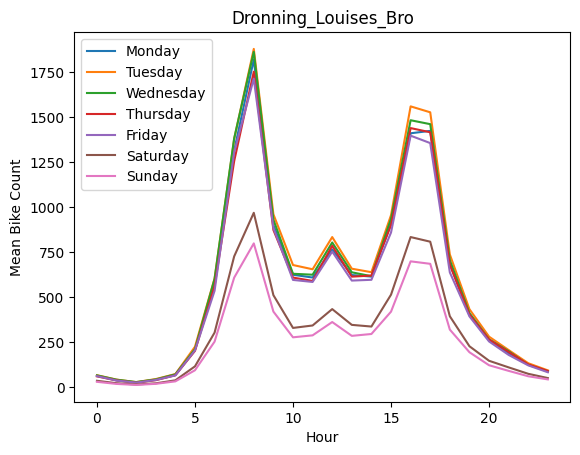

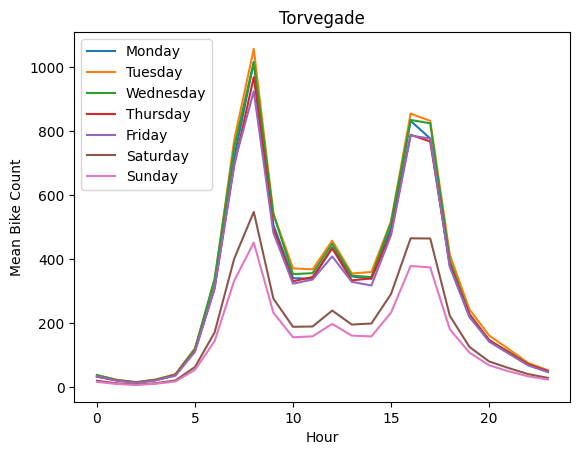

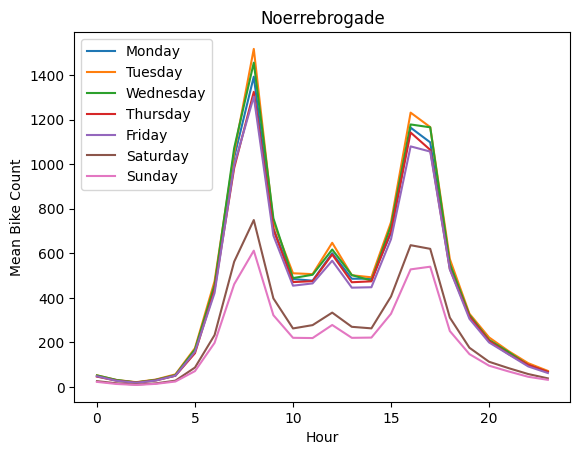

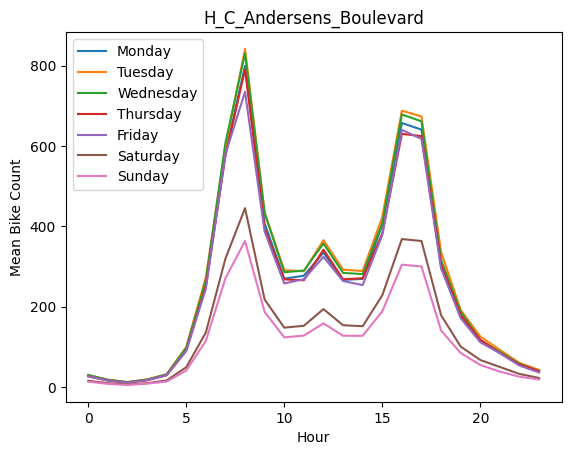

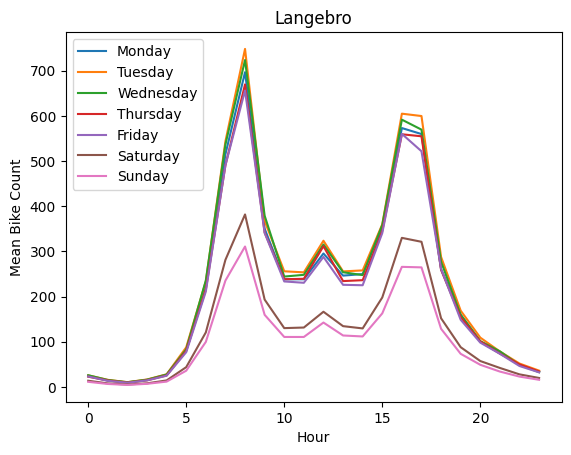

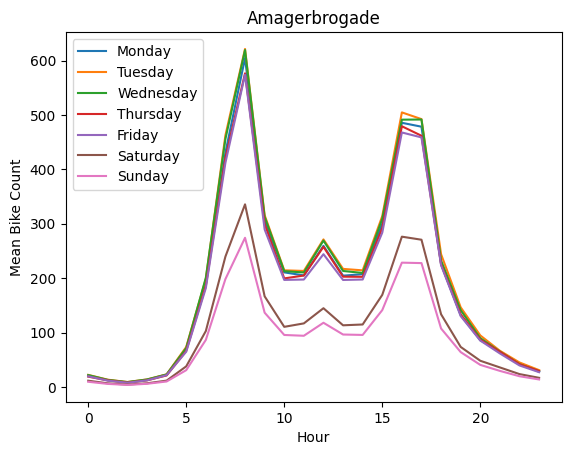

In [36]:
def mean_weekly_rate(Station):
    df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
    df_bike_counts["day_name"] = df_bike_counts["datetime"].dt.day_name()
    df_bike_counts["hour"] = df_bike_counts["datetime"].dt.hour

    mean_weekly = (
        df_bike_counts[df_bike_counts["station"] == Station]
        .groupby(["day_name", "hour"])["bike_count"]
        .mean().unstack()
    )
    
    return mean_weekly

for s in stations:
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekly = mean_weekly_rate(s).reindex(order)
    
    for day in weekly.index:
        plt.plot(weekly.columns, weekly.loc[day], label=day)
    
    plt.title(f"{s}")
    plt.xlabel("Hour")
    plt.ylabel("Mean Bike Count")
    plt.legend()
    plt.show()

### Seasonal Rate

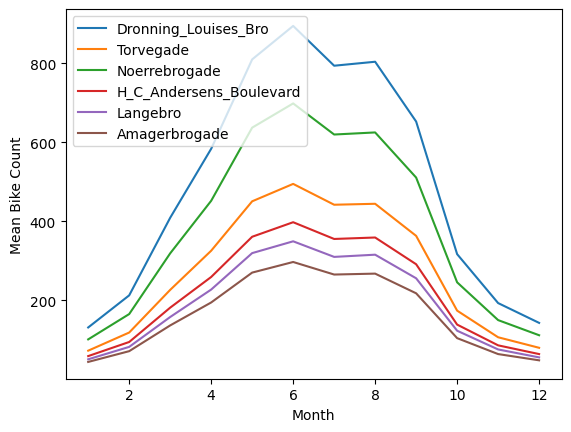

In [37]:
def mean_monthly_rate(Station):
    df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
    df_bike_counts["month"] = df_bike_counts["datetime"].dt.month

    mean_seasonal = (
        df_bike_counts[df_bike_counts["station"] == Station]
        .groupby(["month"])["bike_count"]
        .mean()
    )
    
    return mean_seasonal

for s in stations:
    rate = mean_monthly_rate(s)
    plt.plot(rate.index, rate.values, label=s)

plt.xlabel("Month")
plt.ylabel("Mean Bike Count")
plt.legend()
plt.show()

### Weather Consideration

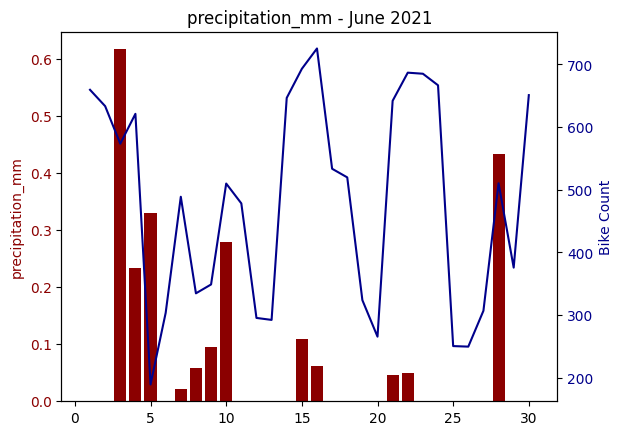

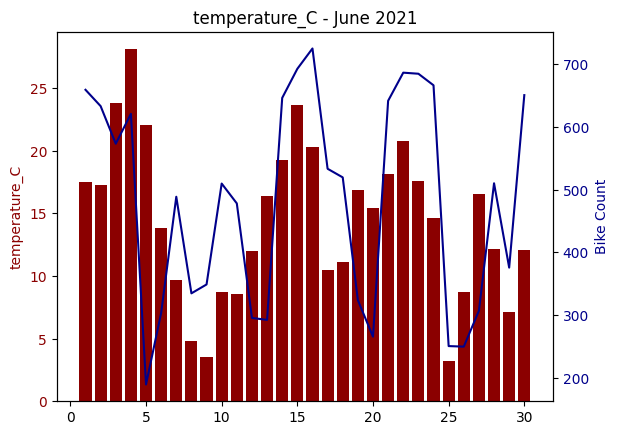

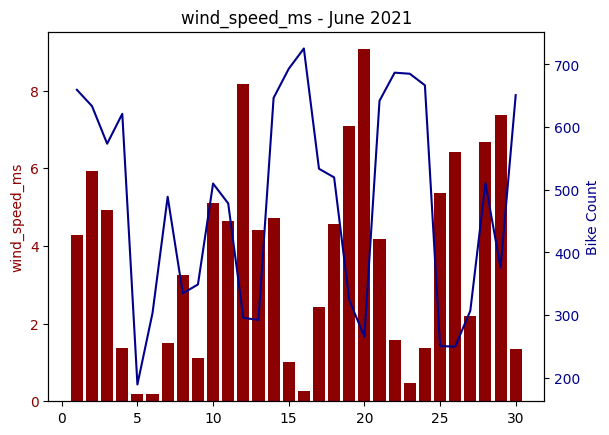

In [38]:
def monthly_weather_rate(Month, Year):
    df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
    df_bike_counts["month"] = df_bike_counts["datetime"].dt.month
    df_bike_counts["year"] = df_bike_counts["datetime"].dt.year
    df_bike_counts["day"] = df_bike_counts["datetime"].dt.day

    df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
    df_merged = pd.merge(df_bike_counts, df_weather, on="datetime")

    df_filtered = df_merged[(df_merged["year"] == Year) & (df_merged["month"] == Month)]

    daily = df_filtered.groupby("day").agg({
        "bike_count": "mean",
        "precipitation_mm": "mean",
        "temperature_C": "mean",
        "wind_speed_ms": "mean"})
    
    return daily

weather_variable = ["precipitation_mm", "temperature_C", "wind_speed_ms"]

for w in weather_variable:
    daily = monthly_weather_rate(6, 2021)
    fig, ax1 = plt.subplots()

    # Weather Variable
    ax1.bar(daily.index, daily[w], color="darkred", label=w)
    ax1.set_ylabel(w, color="darkred")
    ax1.tick_params(axis='y', labelcolor="darkred")

    # Bike count
    ax2 = ax1.twinx()
    ax2.plot(daily.index, daily["bike_count"], color="darkblue", label="Bike Count")
    ax2.set_xlabel("Day")
    ax2.set_ylabel("Bike Count", color="darkblue")
    ax2.tick_params(axis='y', labelcolor="darkblue")

    plt.title(f"{w} - June 2021")
    plt.show()

### Public Holiday

C:\Users\suzan\AppData\Local\Temp\ipykernel_25724\4126716940.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


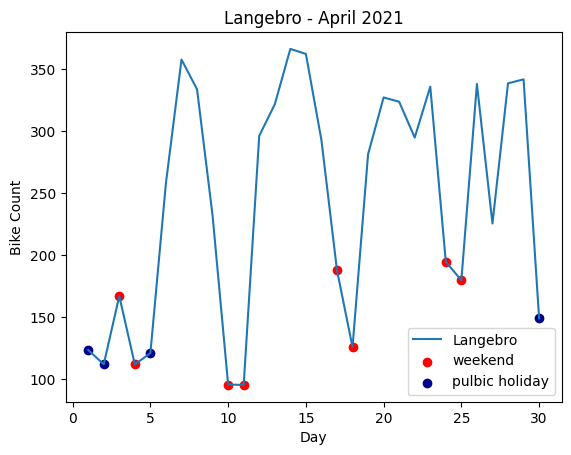

In [105]:
def monthly_holiday_rate(Station, Month, Year):
    df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
    df_bike_counts["month"] = df_bike_counts["datetime"].dt.month
    df_bike_counts["year"] = df_bike_counts["datetime"].dt.year
    df_bike_counts["day"] = df_bike_counts["datetime"].dt.day
    df_bike_counts["weekday"] = df_bike_counts["datetime"].dt.weekday

    df_bike_counts["date"] = df_bike_counts["datetime"].dt.date
    df_holidays["date"] = pd.to_datetime(df_holidays["date"]).dt.date

    df_holidays["holiday"] = True
    df_merged = pd.merge(df_bike_counts, df_holidays, on="date", how="left")

    df_merged["holiday"] = df_merged["holiday"].fillna(False)

    df_filtered = df_merged[(df_merged["year"] == Year) & (df_merged["month"] == Month) & (df_merged["station"] == Station)]
    
    holiday_count = df_filtered.groupby("day").agg({
        "bike_count": "mean",
        "holiday": "max",
        "weekday": "max"})
    
    return holiday_count

data = monthly_holiday_rate("Langebro", 4, 2021)

plt.plot(data.index, data["bike_count"], label="Langebro")
weekend = data[data["weekday"].isin([5, 6])]
holiday_days = data[data["holiday"] != 0]

plt.scatter(weekend.index, weekend["bike_count"], color="red", label="weekend")
plt.scatter(holiday_days.index, holiday_days["bike_count"], color="darkblue", label="pulbic holiday")
plt.xlabel("Day")
plt.ylabel("Bike Count")
plt.title("Langebro - April 2021")
plt.legend()
plt.show()